In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

## Load the data

Load car.csv in to pandas df

In [2]:
data_path = Path().cwd().parent / "data" / "car.csv"
df_car = pd.read_csv(data_path)

In [3]:
df_car.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1728 entries, 0 to 1727
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   price        1728 non-null   object
 1   maintenance  1728 non-null   object
 2   doors        1728 non-null   object
 3   seats        1728 non-null   object
 4   storage      1728 non-null   object
 5   safety       1728 non-null   object
 6   shouldBuy    1728 non-null   object
dtypes: object(7)
memory usage: 94.6+ KB


## Check the distrubution of the data

---
By checking the proportation of data we can have idea about imbalance, and device our strategy

In [4]:
df_car["shouldBuy"].value_counts()

shouldBuy
unacc    1210
acc       384
good       69
vgood      65
Name: count, dtype: int64

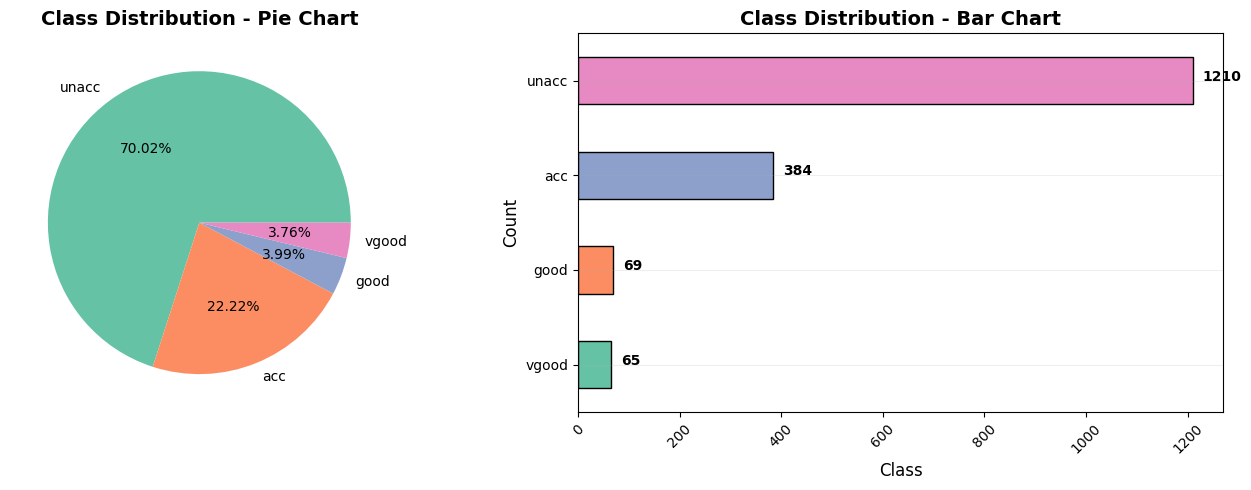

In [5]:
sns.set_palette("Set2")

# Create side-by-side plots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
counts = df_car["shouldBuy"].value_counts().sort_values(ascending=True)
counts.plot(kind="barh", ax=axes[1], edgecolor="black", color=sns.color_palette("Set2"))

axes[1].set_title("Class Distribution - Bar Chart", fontsize=14, fontweight="bold")
axes[1].set_xlabel("Class", fontsize=12)
axes[1].set_ylabel("Count", fontsize=12)
axes[1].tick_params(axis="x", rotation=45)
axes[1].grid(axis="y", alpha=0.2)

for i, v in enumerate(counts.values):
    axes[1].text(v + 20, i, str(int(v)), fontweight="bold")

# Pie chart
df_car["shouldBuy"].value_counts().plot(kind="pie", ax=axes[0], autopct="%1.2f%%", startangle=0)
axes[0].set_title("Class Distribution - Pie Chart", fontsize=14, fontweight="bold")
axes[0].set_ylabel("")

plt.tight_layout()
plt.show()

## Check the unique value for each categorical data
---
By checking the unique value for each categorical data, we can have better idea about the values we have
This  can further help in tranforming the values for consistency

In [6]:
# Create a dictionary of unique values for every column
for col in df_car.columns:
    print(f"{col}: {df_car[col].unique()}")

price: ['vhigh' 'high' 'med' 'low']
maintenance: ['vhigh' 'high' 'med' 'low']
doors: ['2' '3' '4' '5more']
seats: ['2' '4' 'more']
storage: ['small' 'med' 'big']
safety: ['low' 'med' 'high']
shouldBuy: ['unacc' 'acc' 'vgood' 'good']


## Handle the values

---
- Check for missing values, and replace with "mode"
- Check for duplicates, eliminate if found one


In [7]:
print(f"NA values in df_car: {df_car.isna().sum()}")
print(f"Null values in df_car: {df_car.isnull().sum()}")
print(f"Duplicate rows in df_car: {df_car.duplicated().sum()}")

NA values in df_car: price          0
maintenance    0
doors          0
seats          0
storage        0
safety         0
shouldBuy      0
dtype: int64
Null values in df_car: price          0
maintenance    0
doors          0
seats          0
storage        0
safety         0
shouldBuy      0
dtype: int64
Duplicate rows in df_car: 0


In [8]:
# Replace some values with appropriate ones for consistency
df_car["doors"] = df_car["doors"].replace({"5more": "6"})  # replacing '5more' with '6'
df_car["seats"] = df_car["seats"].replace({"more": "6"})  # replacing 'more' with '6' for 6

In [9]:
# handle null, missing,nan,"", etc
# Create a copy to store the final results
def handle_imputation(df_imputed) -> pd.DataFrame:
    # 1. Define the flavors of chaos we injected
    null_flavors = ["", "null", "NaN", "NULL", "none", "None"]

    for col in df_imputed.columns:
        # 2. Replace all string-based nulls with technical np.nan
        # This allows .isna() and imputer functions to work correctly
        df_imputed = df_imputed.replace(null_flavors, np.nan)

        # Check if the column actually has missing values
        if df_imputed[col].isna().any():
            # Case A: Float values -> Use Mean
            if df_imputed[col].dtype == "float64":
                fill_value = df_imputed[col].mean()
                df_imputed[col] = df_imputed[col].fillna(fill_value)

            # Case B: Integer values -> Use Median
            elif df_imputed[col].dtype == "int64":
                fill_value = df_imputed[col].median()
                df_imputed[col] = df_imputed[col].fillna(fill_value)

            # Case C: Categorical/Object (Price, Safety, etc.) -> Use Mode
            else:
                # .mode() returns a Series, so we take the first element [0]
                fill_value = df_imputed[col].mode()[0]
                df_imputed[col] = df_imputed[col].fillna(fill_value)
    return df_imputed


df_car = handle_imputation(df_car)
print(f"Remaining nulls: {df_car.isna().sum().sum()}")

Remaining nulls: 0


In [10]:
# Unique values in each column
for col in df_car.columns:
    print(f"{col}: {df_car[col].unique()}")

price: ['vhigh' 'high' 'med' 'low']
maintenance: ['vhigh' 'high' 'med' 'low']
doors: ['2' '3' '4' '6']
seats: ['2' '4' '6']
storage: ['small' 'med' 'big']
safety: ['low' 'med' 'high']
shouldBuy: ['unacc' 'acc' 'vgood' 'good']


## Tranform DataTypes

---
Convert into appropriate data-types for Model Training/Evaluation

In [11]:
df_car = df_car.astype(
    {
        "price": "string",
        "maintenance": "string",
        "doors": int,
        "seats": int,
        "storage": "string",
        "safety": "string",
        "shouldBuy": "string",
    }
)
df_car.dtypes

price          string[python]
maintenance    string[python]
doors                   int64
seats                   int64
storage        string[python]
safety         string[python]
shouldBuy      string[python]
dtype: object

In [12]:
## Save the df as `parquet` format (columnar storage) for the next steps
data_parquet_path = Path().cwd().parent / "data" / "car.parquet"
df_car.to_parquet(data_parquet_path, index=False)

## EDA is complete
---

Steps Taken:
1. Load the data into pandas DataFrame `df_car`
2. Check the information about dataset - `shape` (# of rows, column, null values, etc.)
3. Check the `distrubition of each class` to check we have balanced dataset or not
4. Check for NA, Missing, NULL, Duplicates, and handle them
5. Handle some values to appropriate form ("5 more" in seats => 6, and "more" in doors => 6)
6. Convert each column into proper `pythonic datatypes` instead of generic objects
7. EDA is complete => Save the dataframe as `parque` format for futher steps